<a href="https://colab.research.google.com/github/Arif1234-cpu/heart_disease_Model/blob/main/heart_disease_classification_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score
import pandas as pd
import Log_Reg as Lr
import matplotlib.pyplot as plt

In [ ]:
heart_data=pd.read_csv('/content/heart_data.csv')

In [ ]:
heart_data.shape


(303, 14)

In [ ]:
heart_data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
# separating features and labels
features=heart_data.drop(columns='target',axis=1)
target=heart_data['target']

In [ ]:
print(features.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  
0   0     1  
1   0     2  
2   0     2  
3   0     2  
4   0     2  


In [ ]:
X_train , X_test , Y_train , Y_test = train_test_split(features , target , test_size=0.2 , random_state=42)

In [ ]:
# Data Standardization
scaler=StandardScaler()
X_train_scaled=scalar.fit_transform(X_train)
X_test_scaled=scalar.transform(X_test)
print(X_train_scaled)

[[-1.35679832  0.72250438  0.00809909 ...  0.95390513 -0.68970073
  -0.50904773]
 [ 0.38508599  0.72250438 -0.97189094 ...  0.95390513 -0.68970073
   1.17848036]
 [-0.92132724  0.72250438  0.98808912 ... -0.69498803 -0.68970073
  -0.50904773]
 ...
 [ 1.58263146  0.72250438  1.96807914 ... -0.69498803  0.32186034
  -0.50904773]
 [-0.92132724  0.72250438 -0.97189094 ...  0.95390513 -0.68970073
   1.17848036]
 [ 0.92942484 -1.38407465  0.00809909 ...  0.95390513  1.33342142
  -0.50904773]]


In [ ]:
import warnings
warnings.filterwarnings('ignore',category=UserWarning)
warnings.filterwarnings('ignore',message='.*getattr.*')

In [ ]:
classifier= Lr.Logistic_Regression(learning_rate=0.001 , no_of_iterations=10000)
classifier.fit(X_train_scaled,Y_train.values)

Iteration 0: Loss = 0.6928
Iteration 100: Loss = 0.6634
Iteration 200: Loss = 0.6375
Iteration 300: Loss = 0.6147
Iteration 400: Loss = 0.5946
Iteration 500: Loss = 0.5767
Iteration 600: Loss = 0.5608
Iteration 700: Loss = 0.5466
Iteration 800: Loss = 0.5339
Iteration 900: Loss = 0.5224
Iteration 1000: Loss = 0.5121
Iteration 1100: Loss = 0.5027
Iteration 1200: Loss = 0.4942
Iteration 1300: Loss = 0.4864
Iteration 1400: Loss = 0.4793
Iteration 1500: Loss = 0.4728
Iteration 1600: Loss = 0.4668
Iteration 1700: Loss = 0.4612
Iteration 1800: Loss = 0.4561
Iteration 1900: Loss = 0.4514
Iteration 2000: Loss = 0.4469
Iteration 2100: Loss = 0.4428
Iteration 2200: Loss = 0.4390
Iteration 2300: Loss = 0.4354
Iteration 2400: Loss = 0.4320
Iteration 2500: Loss = 0.4288
Iteration 2600: Loss = 0.4259
Iteration 2700: Loss = 0.4230
Iteration 2800: Loss = 0.4204
Iteration 2900: Loss = 0.4179
Iteration 3000: Loss = 0.4155
Iteration 3100: Loss = 0.4133
Iteration 3200: Loss = 0.4112
Iteration 3300: Loss =

In [ ]:
X_train_prediction=classifier.predict(X_train_scaled)
training_data_accuracy= accuracy_score(Y_train,X_train_prediction)
print("Accuracy_Score of Training_Data",training_data_accuracy)

Accuracy_Score of Training_Data 0.8512396694214877


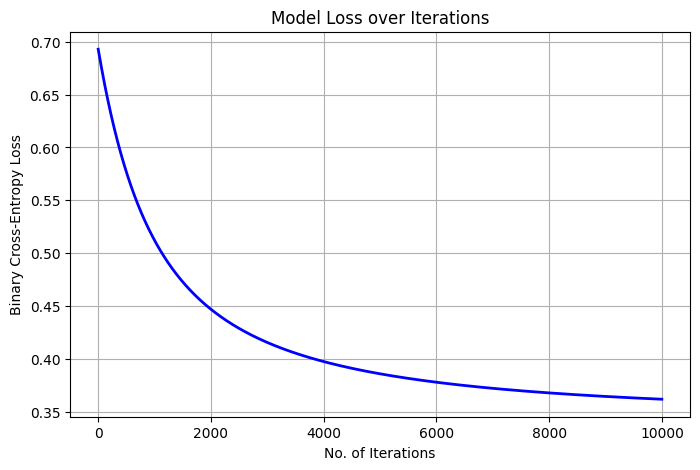

In [ ]:


# Plotting the loss history we stored in fit()
plt.figure(figsize=(8, 5))
plt.plot(classifier.loss_history, color='blue', linewidth=2)
plt.title('Model Loss over Iterations')
plt.xlabel('No. of Iterations')
plt.ylabel('Binary Cross-Entropy Loss')
plt.grid(True)
plt.show()

In [ ]:
# accuracy score on test data
X_test_prediction=classifier.predict(X_test_scaled)
test_data_accuracy= accuracy_score(Y_test , X_test_prediction)

In [ ]:
print('Accuracy Score of Test Data:',test_data_accuracy)

Accuracy Score of Test Data: 0.8852459016393442


In [ ]:
print(X_test.shape)

(61, 13)


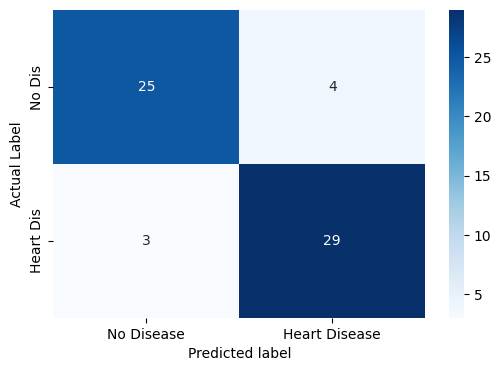

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(Y_test , X_test_prediction)

plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues', xticklabels=['No Disease','Heart Disease'],yticklabels=['No Dis', 'Heart Dis'])

plt.xlabel('Predicted label')
plt.ylabel('Actual Label')
plt.show()

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(Y_test , X_test_prediction , target_names=['No disease',' Heart Disease']))

                precision    recall  f1-score   support

    No disease       0.89      0.86      0.88        29
 Heart Disease       0.88      0.91      0.89        32

      accuracy                           0.89        61
     macro avg       0.89      0.88      0.88        61
  weighted avg       0.89      0.89      0.89        61



In [ ]:
import joblib
joblib.dump(classifier, 'logistic_regression_model.pkl')
joblib.dump(scaler,'data_scaler.pkl')

print("Model and Scaler are  Saved Successfully!")

Model and Scaler are  Saved Successfully!
